# 04. Inspect DMFC Neural Responses

Goal:
- Load Mahler DMFC neural responses.
- Identify the array structure: condition × time × neuron.
- Align neural responses with behavioral model predictions.
- Create time-window-averaged neural tables for later encoding analysis.

Main question for later:
Which variables are reflected in DMFC activity?
- deterministic state
- task difficulty
- MC-derived mean prediction
- response uncertainty
- behavioral deviation

In [1]:
from pathlib import Path
import sys
import types
import pickle
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"

NEURAL_DIR = RAW_DIR / "neural_responses"
HAND_DMFC_DIR = RAW_DIR / "hand_dmfc"

for d in [INTERIM_DIR, PROCESSED_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

NEURAL_PKL = NEURAL_DIR / "offline_mahler_hand_dmfc_neural_responses_reliable_50.pkl"
FULL_MAHLER_PKL = HAND_DMFC_DIR / "mahler_hand_dmfc_dataset_50ms.pkl"

FINAL_BEHAVIOR_PATH = PROCESSED_DIR / "final_behavior_model_predictions_mahler.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("NEURAL_PKL exists:", NEURAL_PKL.exists(), NEURAL_PKL)
print("FULL_MAHLER_PKL exists:", FULL_MAHLER_PKL.exists(), FULL_MAHLER_PKL)
print("FINAL_BEHAVIOR_PATH exists:", FINAL_BEHAVIOR_PATH.exists(), FINAL_BEHAVIOR_PATH)

PROJECT_ROOT: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents
NEURAL_PKL exists: True c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\raw\neural_responses\offline_mahler_hand_dmfc_neural_responses_reliable_50.pkl
FULL_MAHLER_PKL exists: True c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\raw\hand_dmfc\mahler_hand_dmfc_dataset_50ms.pkl
FINAL_BEHAVIOR_PATH exists: True c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\final_behavior_model_predictions_mahler.csv


In [2]:
def patch_old_pandas_pickle():
    module_name = "pandas.core.indexes.numeric"
    
    if module_name not in sys.modules:
        numeric_module = types.ModuleType(module_name)
        numeric_module.Int64Index = pd.Index
        numeric_module.UInt64Index = pd.Index
        numeric_module.Float64Index = pd.Index
        sys.modules[module_name] = numeric_module


def load_pickle_compat(path: Path):
    patch_old_pandas_pickle()
    with open(path, "rb") as f:
        obj = pickle.load(f)
    return obj

In [3]:
assert FINAL_BEHAVIOR_PATH.exists(), f"Missing file: {FINAL_BEHAVIOR_PATH}"

beh = pd.read_csv(FINAL_BEHAVIOR_PATH)

print("behavior prediction shape:", beh.shape)
display(beh.head())
display(beh.columns.to_frame(index=False).T)

behavior prediction shape: (79, 58)


,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred,n_bounce,heading0,speed0,vx_trace_step,vy_trace_step,horizon_steps_occ_to_final,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed,y_det,y_true,y_paddle,abs_y_occ,abs_vy_occ,abs_y_det,signed_paddle_error,abs_paddle_error,pred_M0_det,sigma_M0_det,pred_M1_biased_det,sigma_M1_biased_det,pred_M2_heuristic,sigma_M2_heuristic,pred_M3_mc_ipe,sigma_M3_mc_ipe,uncertainty_M3_mc_ipe,pred_M4_biased_mc_ipe,sigma_M4_biased_mc_ipe,uncertainty_M4_mc,pred_M5_hetero_det,sigma_M5_hetero_det,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,mc_mean_M6,mc_std_M6
0,0,29337.0,41,56,15,5.017654,-2.787992,0.335375,0.167776,10.048274,-0.271351,10.048275,-0.271351,-0.688933,6.364749e-08,6.364749e-08,-0.417582,0.417582,-0.417582,0.417582,1.0,0.463859,0.50,0.335375,0.167776,15,142,0.654930,0.190141,0.154930,1.016034,-0.405027,-0.271351,-0.271351,-0.688933,2.787992,0.167776,0.271351,-0.417582,0.417582,-0.271351,1.512199,-0.387616,1.343921,-0.820229,1.444340,-0.717167,1.547092,0.568326,-0.612109,1.521794,1.463708,-0.387616,0.759767,-0.230727,0.718746,-0.069906,0.948261
1,1,55062.0,41,56,15,5.160105,-8.066386,0.318018,0.198720,9.930375,-5.085588,9.930375,-5.085590,-3.723874,1.861446e-06,1.861446e-06,1.361716,1.361716,1.361714,1.361714,0.0,-0.565065,0.50,0.316708,-0.200801,15,124,0.612903,0.370968,0.016129,1.599905,0.487836,-5.085588,-5.085590,-3.723874,8.066386,0.198720,5.085588,1.361716,1.361716,-5.085588,1.567046,-4.704735,1.356974,-2.815561,1.633471,-5.308730,1.527418,0.290777,-4.955276,1.517295,1.426141,-4.704735,0.635699,-4.839890,0.630025,-5.188814,0.958497
2,2,58244.0,41,56,15,5.148340,-2.995164,0.316708,-0.200802,9.898955,-6.007187,9.890882,-6.007161,-5.745208,-2.628687e-05,2.628687e-05,0.261953,0.261953,0.261979,0.261979,1.0,-0.565065,0.50,0.316708,-0.200802,15,123,0.699187,0.260163,0.040650,1.400058,0.675314,-6.007187,-6.007161,-5.745208,2.995164,0.200802,6.007187,0.261953,0.261953,-6.007187,1.567046,-5.497139,1.356974,-4.740851,1.633471,-5.830621,1.696721,0.793983,-5.694956,1.523911,1.454085,-5.497139,0.644570,-5.584061,0.638817,-6.045057,1.039976
3,3,59920.0,36,49,13,5.222656,-4.450462,0.370473,-0.423268,10.038807,-9.952948,10.040118,-9.766393,-7.246475,-1.865550e-01,1.865550e-01,2.519918,2.519918,2.706473,2.706473,1.0,-0.851814,0.75,0.370473,-0.423268,13,117,0.410256,0.529915,0.059829,2.133472,2.086257,-9.952948,-9.766393,-7.246475,4.450462,0.423268,9.952948,2.519918,2.519918,-9.952948,1.404889,-8.925939,1.239052,-8.834230,1.607278,-9.607169,1.339460,0.156179,-8.132695,1.327884,0.824287,-8.925939,0.627907,-8.336010,0.591463,-9.230822,0.537432
4,4,68220.0,42,58,16,5.200805,1.952503,0.298667,0.226767,9.979475,5.580770,9.979475,5.580769,5.144827,7.902510e-08,7.902510e-08,-0.435943,0.435943,-0.435943,0.435943,0.0,0.649403,0.50,0.298667,0.226767,16,128,0.742188,0.210938,0.046875,1.293350,-0.610159,5.580770,5.580769,5.144827,1.952503,0.226767,5.580770,-0.435943,0.435943,5.580770,1.512199,4.717728,1.343921,3.706159,1.444340,5.451764,1.547547,0.569565,4.894367,1.589112,1.726305,4.717728,0.833022,4.717494,0.788046,5.528507,0.888707


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57
0,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred,n_bounce,heading0,speed0,vx_trace_step,vy_trace_step,horizon_steps_occ_to_final,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed,y_det,y_true,y_paddle,abs_y_occ,abs_vy_occ,abs_y_det,signed_paddle_error,abs_paddle_error,pred_M0_det,sigma_M0_det,pred_M1_biased_det,sigma_M1_biased_det,pred_M2_heuristic,sigma_M2_heuristic,pred_M3_mc_ipe,sigma_M3_mc_ipe,uncertainty_M3_mc_ipe,pred_M4_biased_mc_ipe,sigma_M4_biased_mc_ipe,uncertainty_M4_mc,pred_M5_hetero_det,sigma_M5_hetero_det,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,mc_mean_M6,mc_std_M6


In [4]:
if NEURAL_PKL.exists():
    neural_obj = load_pickle_compat(NEURAL_PKL)
    print("Loaded separate neural file.")
elif FULL_MAHLER_PKL.exists():
    full_obj = load_pickle_compat(FULL_MAHLER_PKL)
    print("Loaded full Mahler dataset.")
    
    print("Top-level keys:")
    for k in full_obj.keys():
        print(" -", k)
    
    neural_obj = full_obj
else:
    raise FileNotFoundError("No neural response file found.")

print("neural_obj type:", type(neural_obj))

Loaded separate neural file.
neural_obj type: <class 'dict'>


In [5]:
def summarize_obj(obj, name="root", max_depth=2, depth=0):
    indent = "  " * depth
    
    if isinstance(obj, pd.DataFrame):
        print(f"{indent}{name}: DataFrame shape={obj.shape}")
        print(f"{indent}  columns={list(obj.columns)[:20]}")
    
    elif isinstance(obj, np.ndarray):
        print(f"{indent}{name}: ndarray shape={obj.shape}, dtype={obj.dtype}, nan_ratio={np.isnan(obj).mean() if np.issubdtype(obj.dtype, np.number) else 'NA'}")
    
    elif isinstance(obj, dict):
        print(f"{indent}{name}: dict len={len(obj)}")
        keys = list(obj.keys())
        print(f"{indent}  keys={keys[:30]}")
        
        if depth < max_depth:
            for k in keys[:20]:
                summarize_obj(obj[k], name=str(k), max_depth=max_depth, depth=depth+1)
    
    elif isinstance(obj, list):
        print(f"{indent}{name}: list len={len(obj)}")
        if len(obj) > 0 and depth < max_depth:
            summarize_obj(obj[0], name=f"{name}[0]", max_depth=max_depth, depth=depth+1)
    
    else:
        print(f"{indent}{name}: {type(obj).__name__} {repr(obj)[:100]}")


summarize_obj(neural_obj, max_depth=3)

root: dict len=1
  keys=['all_metrics']
  all_metrics: dict len=3
    keys=['neural_data', 'pos_state_pred', 'posvel_state_pred']
    neural_data: dict len=12
      keys=['yp', 'yt', 'r_start1_all', 'mae_start1_all', 'r_start1_bounce', 'mae_start1_bounce', 'r_start1_bounce_occ', 'mae_start1_bounce_occ', 'r_start1_bounce_vis', 'mae_start1_bounce_vis', 'r_start1_no_bounce', 'mae_start1_no_bounce']
      yp: ndarray shape=(100, 79, 100), dtype=float64, nan_ratio=0.8697189873417721
      yt: ndarray shape=(100, 79, 100), dtype=float64, nan_ratio=0.7417721518987341
      r_start1_all: ndarray shape=(100, 100), dtype=float64, nan_ratio=0.6335
      mae_start1_all: ndarray shape=(100, 100), dtype=float64, nan_ratio=0.6309
      r_start1_bounce: ndarray shape=(100, 100), dtype=float64, nan_ratio=0.6582
      mae_start1_bounce: ndarray shape=(100, 100), dtype=float64, nan_ratio=0.6463
      r_start1_bounce_occ: ndarray shape=(100, 100), dtype=float64, nan_ratio=0.6887
      mae_start1_bounce_oc

In [6]:
N_COND = beh["condition_i"].nunique()
EXPECTED_TIME = 100

def find_ndarrays(obj, prefix="root"):
    found = []
    
    if isinstance(obj, np.ndarray):
        found.append((prefix, obj))
    
    elif isinstance(obj, dict):
        for k, v in obj.items():
            found.extend(find_ndarrays(v, prefix=f"{prefix}/{k}"))
    
    elif isinstance(obj, list):
        for i, v in enumerate(obj[:20]):
            found.extend(find_ndarrays(v, prefix=f"{prefix}[{i}]"))
    
    return found


arrays_found = find_ndarrays(neural_obj)

array_summary = []
for path, arr in arrays_found:
    shape = arr.shape
    if arr.ndim >= 2:
        contains_ncond = N_COND in shape
        contains_time = EXPECTED_TIME in shape
        maybe_neural = contains_ncond and contains_time
    else:
        contains_ncond = False
        contains_time = False
        maybe_neural = False
    
    array_summary.append({
        "path": path,
        "shape": shape,
        "ndim": arr.ndim,
        "dtype": arr.dtype,
        "contains_ncond_79": contains_ncond,
        "contains_time_100": contains_time,
        "maybe_neural": maybe_neural,
        "nan_ratio": np.isnan(arr).mean() if np.issubdtype(arr.dtype, np.number) else np.nan,
    })

array_summary_df = pd.DataFrame(array_summary).sort_values(
    ["maybe_neural", "contains_ncond_79", "contains_time_100"],
    ascending=False
)

display(array_summary_df.head(50))

,path,shape,ndim,dtype,contains_ncond_79,contains_time_100,maybe_neural,nan_ratio
0,root/all_metrics/neural_data/yp,"(100, 79, 100)",3,float64,True,True,True,0.869719
1,root/all_metrics/neural_data/yt,"(100, 79, 100)",3,float64,True,True,True,0.741772
12,root/all_metrics/pos_state_pred/yp,"(100, 79, 100)",3,float64,True,True,True,0.869719
13,root/all_metrics/pos_state_pred/yt,"(100, 79, 100)",3,float64,True,True,True,0.741772
24,root/all_metrics/posvel_state_pred/yp,"(100, 79, 100)",3,float64,True,True,True,0.869719
25,root/all_metrics/posvel_state_pred/yt,"(100, 79, 100)",3,float64,True,True,True,0.741772
2,root/all_metrics/neural_data/r_start1_all,"(100, 100)",2,float64,False,True,False,0.633500
3,root/all_metrics/neural_data/mae_start1_all,"(100, 100)",2,float64,False,True,False,0.630900
4,root/all_metrics/neural_data/r_start1_bounce,"(100, 100)",2,float64,False,True,False,0.658200
5,root/all_metrics/neural_data/mae_start1_bounce,"(100, 100)",2,float64,False,True,False,0.646300


In [7]:
candidate_paths = array_summary_df.loc[array_summary_df["maybe_neural"], "path"].tolist()

print("Candidate neural arrays:")
for i, p in enumerate(candidate_paths):
    print(f"{i}: {p}")

assert len(candidate_paths) > 0, "No candidate neural array found. Inspect array_summary_df."

SELECTED_PATH = candidate_paths[0]
print("SELECTED_PATH:", SELECTED_PATH)

Candidate neural arrays:
0: root/all_metrics/neural_data/yp
1: root/all_metrics/neural_data/yt
2: root/all_metrics/pos_state_pred/yp
3: root/all_metrics/pos_state_pred/yt
4: root/all_metrics/posvel_state_pred/yp
5: root/all_metrics/posvel_state_pred/yt
SELECTED_PATH: root/all_metrics/neural_data/yp


In [8]:
def get_by_path(obj, path):
    """
    Path format:
        root/key1/key2
    """
    parts = path.split("/")
    assert parts[0] == "root"
    
    cur = obj
    for part in parts[1:]:
        cur = cur[part]
    
    return cur


neural_raw = get_by_path(neural_obj, SELECTED_PATH)

print("selected neural_raw shape:", neural_raw.shape)
print("dtype:", neural_raw.dtype)
print("nan_ratio:", np.isnan(neural_raw).mean())

selected neural_raw shape: (100, 79, 100)
dtype: float64
nan_ratio: 0.8697189873417721


In [9]:
def orient_neural_array(arr, n_cond=79, n_time=100):
    """
    Convert neural array to shape:
        condition × time × unit
    """
    arr = np.asarray(arr)
    shape = arr.shape
    
    cond_axes = [i for i, s in enumerate(shape) if s == n_cond]
    time_axes = [i for i, s in enumerate(shape) if s == n_time]
    
    if len(cond_axes) == 0:
        raise ValueError(f"No condition axis of size {n_cond} found in shape {shape}")
    if len(time_axes) == 0:
        raise ValueError(f"No time axis of size {n_time} found in shape {shape}")
    
    cond_axis = cond_axes[0]
    time_axis = time_axes[0]
    
    unit_axes = [i for i in range(arr.ndim) if i not in [cond_axis, time_axis]]
    
    if len(unit_axes) == 0:
        # condition × time only
        oriented = np.expand_dims(np.moveaxis(arr, [cond_axis, time_axis], [0, 1]), axis=-1)
    elif len(unit_axes) == 1:
        unit_axis = unit_axes[0]
        oriented = np.moveaxis(arr, [cond_axis, time_axis, unit_axis], [0, 1, 2])
    else:
        # flatten remaining dimensions as units
        moved = np.moveaxis(arr, [cond_axis, time_axis] + unit_axes, list(range(arr.ndim)))
        oriented = moved.reshape(n_cond, n_time, -1)
    
    return oriented, {
        "original_shape": shape,
        "cond_axis": cond_axis,
        "time_axis": time_axis,
        "unit_axes": unit_axes,
        "oriented_shape": oriented.shape,
    }


neural_ctu, orient_info = orient_neural_array(
    neural_raw,
    n_cond=N_COND,
    n_time=EXPECTED_TIME,
)

print(orient_info)
print("neural_ctu shape:", neural_ctu.shape)

{'original_shape': (100, 79, 100), 'cond_axis': 1, 'time_axis': 0, 'unit_axes': [2], 'oriented_shape': (79, 100, 100)}
neural_ctu shape: (79, 100, 100)


In [10]:
n_cond, n_time, n_units = neural_ctu.shape

print("n_cond:", n_cond)
print("n_time:", n_time)
print("n_units:", n_units)
print("nan ratio:", np.isnan(neural_ctu).mean())

unit_mean = np.nanmean(neural_ctu, axis=(0, 1))
unit_std = np.nanstd(neural_ctu, axis=(0, 1))

unit_summary = pd.DataFrame({
    "unit": np.arange(n_units),
    "mean": unit_mean,
    "std": unit_std,
    "nan_ratio": np.isnan(neural_ctu).mean(axis=(0, 1)),
})

display(unit_summary.describe())
display(unit_summary.head())

n_cond: 79
n_time: 100
n_units: 100
nan ratio: 0.8697189873417721


,unit,mean,std,nan_ratio
count,100.000000,37.000000,37.000000,100.000000
mean,49.500000,-0.506656,3.660598,0.869719
std,29.011492,0.745611,0.777387,0.198913
min,0.000000,-1.464996,1.898099,0.493671
25%,24.750000,-1.013333,3.532017,0.738766
50%,49.500000,-0.600090,3.774292,1.000000
75%,74.250000,-0.287069,4.075301,1.000000
max,99.000000,2.791465,4.611208,1.000000


,unit,mean,std,nan_ratio
0,0,-0.388610,1.898099,0.493671
1,1,-0.216546,1.899808,0.493671
2,2,0.512602,1.944826,0.493671
3,3,0.438525,1.992038,0.493671
4,4,-0.287069,2.271062,0.493671


In [11]:
event_cols = ["condition_i", "occ_idx", "final_idx", "n_steps", "y_occ", "vy_occ", "y_true", "y_paddle"]
event_cols = [c for c in event_cols if c in beh.columns]

display(beh[event_cols].head())
display(beh[event_cols].describe())

,condition_i,occ_idx,final_idx,n_steps,y_occ,vy_occ,y_true,y_paddle
0,0,41,56,15,-2.787992,0.167776,-0.271351,-0.688933
1,1,41,56,15,-8.066386,0.198720,-5.085590,-3.723874
2,2,41,56,15,-2.995164,-0.200802,-6.007161,-5.745208
3,3,36,49,13,-4.450462,-0.423268,-9.766393,-7.246475
4,4,42,58,16,1.952503,0.226767,5.580769,5.144827


,condition_i,occ_idx,final_idx,n_steps,y_occ,vy_occ,y_true,y_paddle
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,39.000000,30.822785,49.329114,18.506329,-0.605614,0.012232,-0.505324,-0.628778
std,22.949219,6.726830,10.618950,5.843852,5.303557,0.225362,5.400964,4.965906
min,0.000000,19.000000,34.000000,13.000000,-9.792950,-0.423268,-9.766393,-7.246475
25%,19.500000,24.500000,41.500000,15.000000,-4.468215,-0.200802,-5.397608,-5.832213
50%,39.000000,31.000000,48.000000,16.000000,-1.426503,0.108282,-0.951839,-1.275821
75%,58.500000,37.000000,55.000000,19.000000,3.135593,0.205177,4.697695,4.725959
max,78.000000,42.000000,76.000000,35.000000,9.631794,0.429457,8.901912,6.920324


In [12]:
def safe_window_indices(start, end, n_time):
    start = int(max(0, start))
    end = int(min(n_time, end))
    if end <= start:
        return np.array([], dtype=int)
    return np.arange(start, end)


def get_windows_for_condition(row, n_time):
    oi = int(row["occ_idx"])
    fi = int(row["final_idx"])
    
    windows = {
        "pre_occ": safe_window_indices(oi - 5, oi, n_time),
        "early_occ": safe_window_indices(oi, oi + 5, n_time),
        "late_occ": safe_window_indices(fi - 5, fi, n_time),
        "full_occ": safe_window_indices(oi, fi + 1, n_time),
    }
    return windows

In [13]:
neural_window_rows = []

for _, row in beh.iterrows():
    ci = int(row["condition_i"])
    windows = get_windows_for_condition(row, n_time=n_time)
    
    for win_name, idx in windows.items():
        if len(idx) == 0:
            vec = np.full(n_units, np.nan)
        else:
            vec = np.nanmean(neural_ctu[ci, idx, :], axis=0)
        
        out = {
            "condition_i": ci,
            "window": win_name,
        }
        
        for u in range(n_units):
            out[f"unit_{u:03d}"] = vec[u]
        
        neural_window_rows.append(out)

neural_window_df = pd.DataFrame(neural_window_rows)

print("neural_window_df shape:", neural_window_df.shape)
display(neural_window_df.head())

neural_window_df shape: (316, 102)


,condition_i,window,unit_000,unit_001,unit_002,unit_003,unit_004,unit_005,unit_006,unit_007,unit_008,unit_009,unit_010,unit_011,unit_012,unit_013,unit_014,unit_015,unit_016,unit_017,unit_018,unit_019,unit_020,unit_021,unit_022,unit_023,unit_024,unit_025,unit_026,unit_027,unit_028,unit_029,unit_030,unit_031,unit_032,unit_033,unit_034,unit_035,unit_036,unit_037,unit_038,unit_039,unit_040,unit_041,unit_042,unit_043,unit_044,unit_045,unit_046,unit_047,unit_048,unit_049,unit_050,unit_051,unit_052,unit_053,unit_054,unit_055,unit_056,unit_057,unit_058,unit_059,unit_060,unit_061,unit_062,unit_063,unit_064,unit_065,unit_066,unit_067,unit_068,unit_069,unit_070,unit_071,unit_072,unit_073,unit_074,unit_075,unit_076,unit_077,unit_078,unit_079,unit_080,unit_081,unit_082,unit_083,unit_084,unit_085,unit_086,unit_087,unit_088,unit_089,unit_090,unit_091,unit_092,unit_093,unit_094,unit_095,unit_096,unit_097,unit_098,unit_099
0,0,pre_occ,-0.590960,1.379389,0.452114,0.537548,1.522249,-0.845046,2.053754,3.514321,1.697143,2.149586,1.698270,-1.102545,0.703921,-1.271515,-0.474848,-0.388881,0.780072,-0.779988,-2.119404,-1.273460,-0.998197,1.117492,-0.555672,1.296359,-1.555603,-0.746918,-2.046147,0.234285,-1.294374,-0.088340,-0.510056,0.663737,-2.616444,0.710196,-0.373478,-0.741576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,early_occ,-1.761323,0.703368,0.012818,0.263659,2.038235,-0.463798,3.206495,1.438544,1.285506,2.240759,1.433952,-2.121635,1.021560,-0.667143,-1.678263,-0.785434,1.103000,-0.775119,-2.028484,-1.319110,-0.473471,0.061597,-0.968218,1.620691,-1.107949,-2.157704,-2.545793,0.926265,-1.978958,0.311227,-0.906618,1.396752,-2.399197,1.016280,0.208842,0.373721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,late_occ,-2.529047,0.405583,0.375527,0.746150,1.569107,-0.512101,1.947588,1.768042,0.911661,1.733232,-0.286895,-2.597691,0.091238,-0.954154,-2.467268,-1.589378,0.313071,-1.654406,-3.050250,-2.382095,-1.104586,-0.694091,-1.492470,0.149023,-2.130489,-1.784460,-2.654677,0.089028,-1.202022,-0.381539,-1.281830,0.054391,-2.541745,0.237296,-0.538895,-0.089518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,full_occ,-2.042917,0.574913,0.263535,0.597847,1.957729,-0.368715,2.752251,1.709203,1.200211,2.067702,0.820758,-2.194163,0.802000,-0.663379,-1.848456,-0.955042,0.913092,-1.056834,-2.308680,-1.638676,-0.668167,-0.124003,-1.025869,1.175345,-1.373847,-1.873472,-2.381988,0.716753,-1.594069,0.134549,-1.081084,0.886147,-2.342833,0.531793,0.015582,0.216616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,pre_occ,-2.220414,1.091496,1.904289,3.846112,3.903780,6.124102,0.619973,-0.762518,-2.032261,-0.873658,-0.481812,-0.251142,-1.915704,-3.027806,-2.344835,0.010609,-3.411875,-0.369862,0.069634,-3.658249,-0.048835,1.172766,-0.824581,1.367083,-2.426150,-0.699432,-0.948926,-3.675928,-3.672379,-4.092218,-2.057980,-0.646575,-1.043353,2.374046,-1.110544,-3.177302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
feature_cols = [
    "condition_i",
    "y_det",
    "y_true",
    "y_paddle",
    "y_occ",
    "vy_occ",
    "abs_vy_occ",
    "n_steps",
    "n_bounce",
    "pred_M6_mc_mean_task_uncertainty",
    "sigma_M6_mc_mean_task_uncertainty",
    "mc_mean_M6",
    "mc_std_M6",
    "pred_M4_biased_mc_ipe",
    "sigma_M4_biased_mc_ipe",
    "uncertainty_M4_mc",
]

feature_cols = [c for c in feature_cols if c in beh.columns]

analysis_df = neural_window_df.merge(
    beh[feature_cols],
    on="condition_i",
    how="left",
)

print("analysis_df shape:", analysis_df.shape)
display(analysis_df.head())

analysis_df shape: (316, 117)


,condition_i,window,unit_000,unit_001,unit_002,unit_003,unit_004,unit_005,unit_006,unit_007,unit_008,unit_009,unit_010,unit_011,unit_012,unit_013,unit_014,unit_015,unit_016,unit_017,unit_018,unit_019,unit_020,unit_021,unit_022,unit_023,unit_024,unit_025,unit_026,unit_027,unit_028,unit_029,unit_030,unit_031,unit_032,unit_033,unit_034,unit_035,unit_036,unit_037,unit_038,unit_039,unit_040,unit_041,unit_042,unit_043,unit_044,unit_045,unit_046,unit_047,unit_048,unit_049,unit_050,unit_051,unit_052,unit_053,unit_054,unit_055,unit_056,unit_057,unit_058,unit_059,unit_060,unit_061,unit_062,unit_063,unit_064,unit_065,unit_066,unit_067,unit_068,unit_069,unit_070,unit_071,unit_072,unit_073,unit_074,unit_075,unit_076,unit_077,unit_078,unit_079,unit_080,unit_081,unit_082,unit_083,unit_084,unit_085,unit_086,unit_087,unit_088,unit_089,unit_090,unit_091,unit_092,unit_093,unit_094,unit_095,unit_096,unit_097,unit_098,unit_099,y_det,y_true,y_paddle,y_occ,vy_occ,abs_vy_occ,n_steps,n_bounce,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,mc_mean_M6,mc_std_M6,pred_M4_biased_mc_ipe,sigma_M4_biased_mc_ipe,uncertainty_M4_mc
0,0,pre_occ,-0.590960,1.379389,0.452114,0.537548,1.522249,-0.845046,2.053754,3.514321,1.697143,2.149586,1.698270,-1.102545,0.703921,-1.271515,-0.474848,-0.388881,0.780072,-0.779988,-2.119404,-1.273460,-0.998197,1.117492,-0.555672,1.296359,-1.555603,-0.746918,-2.046147,0.234285,-1.294374,-0.088340,-0.510056,0.663737,-2.616444,0.710196,-0.373478,-0.741576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
1,0,early_occ,-1.761323,0.703368,0.012818,0.263659,2.038235,-0.463798,3.206495,1.438544,1.285506,2.240759,1.433952,-2.121635,1.021560,-0.667143,-1.678263,-0.785434,1.103000,-0.775119,-2.028484,-1.319110,-0.473471,0.061597,-0.968218,1.620691,-1.107949,-2.157704,-2.545793,0.926265,-1.978958,0.311227,-0.906618,1.396752,-2.399197,1.016280,0.208842,0.373721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
2,0,late_occ,-2.529047,0.405583,0.375527,0.746150,1.569107,-0.512101,1.947588,1.768042,0.911661,1.733232,-0.286895,-2.597691,0.091238,-0.954154,-2.467268,-1.589378,0.313071,-1.654406,-3.050250,-2.382095,-1.104586,-0.694091,-1.492470,0.149023,-2.130489,-1.784460,-2.654677,0.089028,-1.202022,-0.381539,-1.281830,0.054391,-2.541745,0.237296,-0.538895,-0.089518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
3,0,full_occ,-2.042917,0.574913,0.263535,0.597847,1.957729,-0.368715,2.752251,1.709203,1.200211,2.067702,0.820758,-2.194163,0.802000,-0.663379,-1.848456,-0.955042,0.913092,-1.056834,-2.308680,-1.638676,-0.668167,-0.124003,-1.025869,1.175345,-1.373847,-1.873472,-2.381988,0.716753,-1.594069,0.134549,-1.081084,0.886147,-2.342833,0.531793,0.015582,0.216616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271351,-0.271351,-0.6

In [16]:
unit_cols = [c for c in analysis_df.columns if isinstance(c, str) and c.startswith("unit_")]

print("Number of unit columns:", len(unit_cols))
print("analysis_df shape:", analysis_df.shape)

assert len(unit_cols) > 0, "No unit columns found. Check neural_window_df / analysis_df construction."

X_raw = analysis_df[unit_cols].to_numpy(dtype=float)

print("X_raw shape:", X_raw.shape)
print("Overall finite ratio:", np.isfinite(X_raw).mean())

# 1. Drop units that are almost entirely NaN or have zero variance
finite_ratio_by_unit = np.isfinite(X_raw).mean(axis=0)
unit_mean = np.nanmean(X_raw, axis=0)
unit_std = np.nanstd(X_raw, axis=0)

keep_units = (
    (finite_ratio_by_unit >= 0.5) &
    np.isfinite(unit_mean) &
    np.isfinite(unit_std) &
    (unit_std > 1e-8)
)

print("Units before filtering:", X_raw.shape[1])
print("Units after filtering:", keep_units.sum())

if keep_units.sum() == 0:
    unit_quality_df = pd.DataFrame({
        "unit": unit_cols,
        "finite_ratio": finite_ratio_by_unit,
        "mean": unit_mean,
        "std": unit_std,
    })
    display(unit_quality_df.sort_values("finite_ratio").head(20))
    raise ValueError("No usable neural units after filtering. Inspect selected neural array or window extraction.")

kept_unit_cols = [c for c, keep in zip(unit_cols, keep_units) if keep]
X = X_raw[:, keep_units]

# 2. Drop rows that are entirely NaN
finite_ratio_by_row = np.isfinite(X).mean(axis=1)
keep_rows = finite_ratio_by_row > 0

print("Rows before filtering:", X.shape[0])
print("Rows after filtering:", keep_rows.sum())

if keep_rows.sum() < 2:
    row_quality_df = analysis_df[["condition_i", "window"]].copy()
    row_quality_df["finite_ratio"] = finite_ratio_by_row
    display(row_quality_df.head(20))
    raise ValueError("Too few usable rows for PCA.")

X = X[keep_rows]

# 3. Impute remaining NaNs with unit mean
col_mean = np.nanmean(X, axis=0)

inds = np.where(~np.isfinite(X))
X[inds] = np.take(col_mean, inds[1])

# 4. Standardize units
X_mean = X.mean(axis=0, keepdims=True)
X_std = X.std(axis=0, keepdims=True)
X_std[X_std < 1e-8] = 1.0

Xz = (X - X_mean) / X_std

print("Xz shape:", Xz.shape)

# 5. PCA by SVD
U, S, Vt = np.linalg.svd(Xz, full_matrices=False)

n_pcs = min(5, U.shape[1], len(S))
scores = U[:, :n_pcs] * S[:n_pcs]

explained = (S ** 2) / np.sum(S ** 2)

print("Number of PCs:", n_pcs)
print("Explained variance first 10 PCs:")
print(explained[:10])

pca_df = analysis_df.loc[keep_rows, ["condition_i", "window"]].copy().reset_index(drop=True)

for i in range(n_pcs):
    pca_df[f"PC{i+1}"] = scores[:, i]

# Ensure PC1~PC3 columns exist for later cells
for pc in ["PC1", "PC2", "PC3"]:
    if pc not in pca_df.columns:
        pca_df[pc] = np.nan

display(pca_df.head())

Number of unit columns: 100
analysis_df shape: (316, 117)
X_raw shape: (316, 100)
Overall finite ratio: 0.25174050632911393
Units before filtering: 100
Units after filtering: 25
Rows before filtering: 316
Rows after filtering: 308
Xz shape: (308, 25)
Number of PCs: 5
Explained variance first 10 PCs:
[0.55418334 0.08624483 0.05440942 0.04504976 0.04021707 0.0355192
 0.03032891 0.02055932 0.01817225 0.01651867]


,condition_i,window,PC1,PC2,PC3,PC4,PC5
0,0,pre_occ,1.429697,0.147761,-0.716712,-0.053119,0.679704
1,0,early_occ,1.235810,0.132941,-0.335846,0.636141,0.906960
2,0,late_occ,0.243098,0.635230,-0.259377,0.859541,0.640063
3,0,full_occ,0.989002,0.315490,-0.394452,0.756840,0.760405
4,1,pre_occ,0.600908,0.574002,-2.835429,2.607552,0.632770


Available PCs: ['PC1', 'PC2', 'PC3']


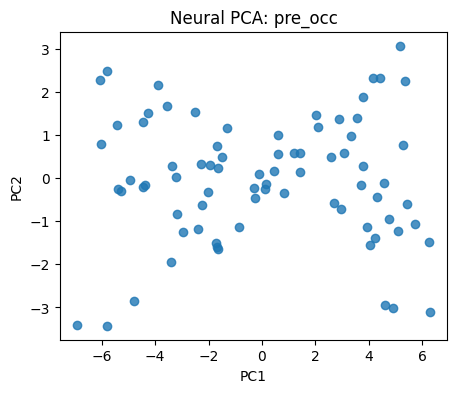

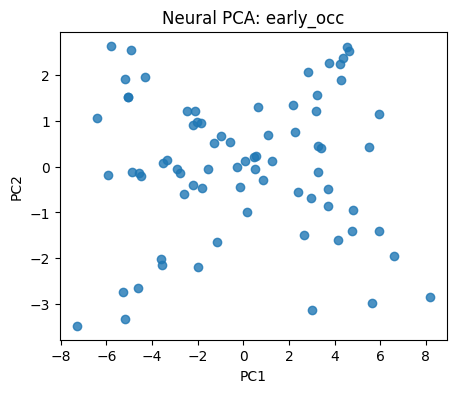

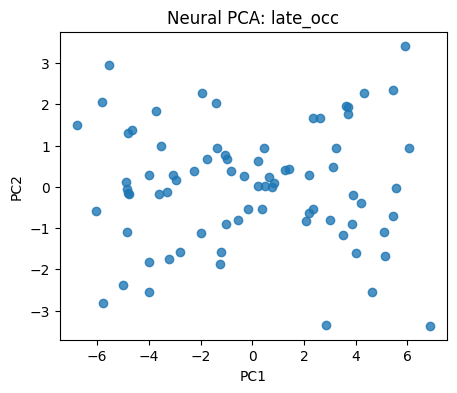

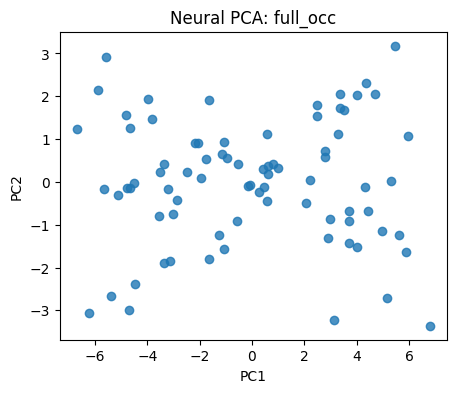

In [17]:
available_pcs = [c for c in ["PC1", "PC2", "PC3"] if c in pca_df.columns and np.isfinite(pca_df[c]).any()]

print("Available PCs:", available_pcs)

if "PC1" in available_pcs and "PC2" in available_pcs:
    for win in pca_df["window"].unique():
        sub = pca_df[pca_df["window"] == win]

        plt.figure(figsize=(5, 4))
        plt.scatter(sub["PC1"], sub["PC2"], alpha=0.8)
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title(f"Neural PCA: {win}")
        plt.show()
else:
    print("Not enough PCs for PC1-PC2 plotting.")

In [18]:
pca_analysis_df = pca_df.merge(
    beh[feature_cols],
    on="condition_i",
    how="left",
)

candidate_vars = [
    "y_det",
    "y_paddle",
    "y_occ",
    "vy_occ",
    "abs_vy_occ",
    "n_steps",
    "pred_M6_mc_mean_task_uncertainty",
    "sigma_M6_mc_mean_task_uncertainty",
    "mc_mean_M6",
    "mc_std_M6",
]

candidate_vars = [c for c in candidate_vars if c in pca_analysis_df.columns]

pc_cols = [c for c in ["PC1", "PC2", "PC3"] if c in pca_analysis_df.columns and np.isfinite(pca_analysis_df[c]).any()]

corr_rows = []

for win in pca_analysis_df["window"].unique():
    sub = pca_analysis_df[pca_analysis_df["window"] == win]

    for pc in pc_cols:
        for var in candidate_vars:
            valid = np.isfinite(sub[pc]) & np.isfinite(sub[var])

            if valid.sum() >= 5:
                corr = np.corrcoef(sub.loc[valid, pc], sub.loc[valid, var])[0, 1]
            else:
                corr = np.nan

            corr_rows.append({
                "window": win,
                "pc": pc,
                "var": var,
                "n_valid": int(valid.sum()),
                "corr": corr,
                "abs_corr": abs(corr) if np.isfinite(corr) else np.nan,
            })

corr_preview = pd.DataFrame(corr_rows).sort_values("abs_corr", ascending=False)

display(corr_preview.head(30))

,window,pc,var,n_valid,corr,abs_corr
1,pre_occ,PC1,y_paddle,77,0.932267,0.932267
91,full_occ,PC1,y_paddle,79,0.921854,0.921854
31,early_occ,PC1,y_paddle,75,0.915626,0.915626
61,late_occ,PC1,y_paddle,77,0.902790,0.902790
6,pre_occ,PC1,pred_M6_mc_mean_task_uncertainty,77,0.899725,0.899725
8,pre_occ,PC1,mc_mean_M6,77,0.899482,0.899482
0,pre_occ,PC1,y_det,77,0.897411,0.897411
98,full_occ,PC1,mc_mean_M6,79,0.889307,0.889307
96,full_occ,PC1,pred_M6_mc_mean_task_uncertainty,79,0.889264,0.889264
38,early_occ,PC1,mc_mean_M6,75,0.887990,0.887990


In [19]:
NEURAL_NPZ_PATH = INTERIM_DIR / "mahler_neural_ctu.npz"
NEURAL_WINDOW_PATH = INTERIM_DIR / "mahler_neural_window_features.csv"
ANALYSIS_PATH = PROCESSED_DIR / "mahler_neural_behavior_window_analysis.csv"
PCA_PATH = PROCESSED_DIR / "mahler_neural_pca_preview.csv"
CORR_PATH = PROCESSED_DIR / "mahler_neural_pc_corr_preview.csv"

np.savez_compressed(
    NEURAL_NPZ_PATH,
    neural_ctu=neural_ctu,
)

neural_window_df.to_csv(NEURAL_WINDOW_PATH, index=False)
analysis_df.to_csv(ANALYSIS_PATH, index=False)
pca_analysis_df.to_csv(PCA_PATH, index=False)
corr_preview.to_csv(CORR_PATH, index=False)

print("Saved:", NEURAL_NPZ_PATH)
print("Saved:", NEURAL_WINDOW_PATH)
print("Saved:", ANALYSIS_PATH)
print("Saved:", PCA_PATH)
print("Saved:", CORR_PATH)

Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\interim\mahler_neural_ctu.npz
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\interim\mahler_neural_window_features.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\mahler_neural_behavior_window_analysis.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\mahler_neural_pca_preview.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\mahler_neural_pc_corr_preview.csv
